#Random Forest

Dataset Description:

Use the Glass dataset and apply the Random forest model.

1. Exploratory Data Analysis (EDA):

Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, inconsistencies in the data.

2: Data Visualization:

Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
Analyze any patterns or correlations observed in the data.

3: Data Preprocessing

1. Check for missing values in the dataset and decide on a strategy for handling them.Implement the chosen strategy (e.g., imputation or removal) and explain your reasoning.
2. If there are categorical variables, apply encoding techniques like one-hot encoding to convert them into numerical format.
3. Apply feature scaling techniques such as standardization or normalization to ensure that all features are on a similar scale. Handling the imbalance data.

4: Random Forest Model Implementation
1. Divide the data into train and test split.
2. Implement a Random Forest classifier using Python and a machine learning library like scikit-learn.
3. Train the model on the train dataset. Evaluate the performance on test data using metrics like accuracy, precision, recall, and F1-score.

5: Bagging and Boosting Methods
Apply the Bagging and Boosting methods and compare the results.


Additional Notes:
1. Explain Bagging and Boosting methods. How is it different from each other.
2. Explain how to handle imbalance in the data.

Dataset Shape: (214, 10)
        RI     Na    Mg    Al     Si     K     Ca   Ba    Fe  \
0  1.51793  12.79  3.50  1.12  73.03  0.64   8.77  0.0  0.00   
1  1.51643  12.16  3.52  1.35  72.89  0.57   8.53  0.0  0.00   
2  1.51793  13.21  3.48  1.41  72.64  0.59   8.43  0.0  0.00   
3  1.51299  14.40  1.74  1.54  74.55  0.00   7.59  0.0  0.00   
4  1.53393  12.30  0.00  1.00  70.16  0.12  16.19  0.0  0.24   

                   Type  
0      build wind float  
1      vehic wind float  
2      build wind float  
3             tableware  
4  build wind non-float  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   RI      214 non-null    float64 
 1   Na      214 non-null    float64 
 2   Mg      214 non-null    float64 
 3   Al      214 non-null    float64 
 4   Si      214 non-null    float64 
 5   K       214 non-null    float64 
 6   Ca   

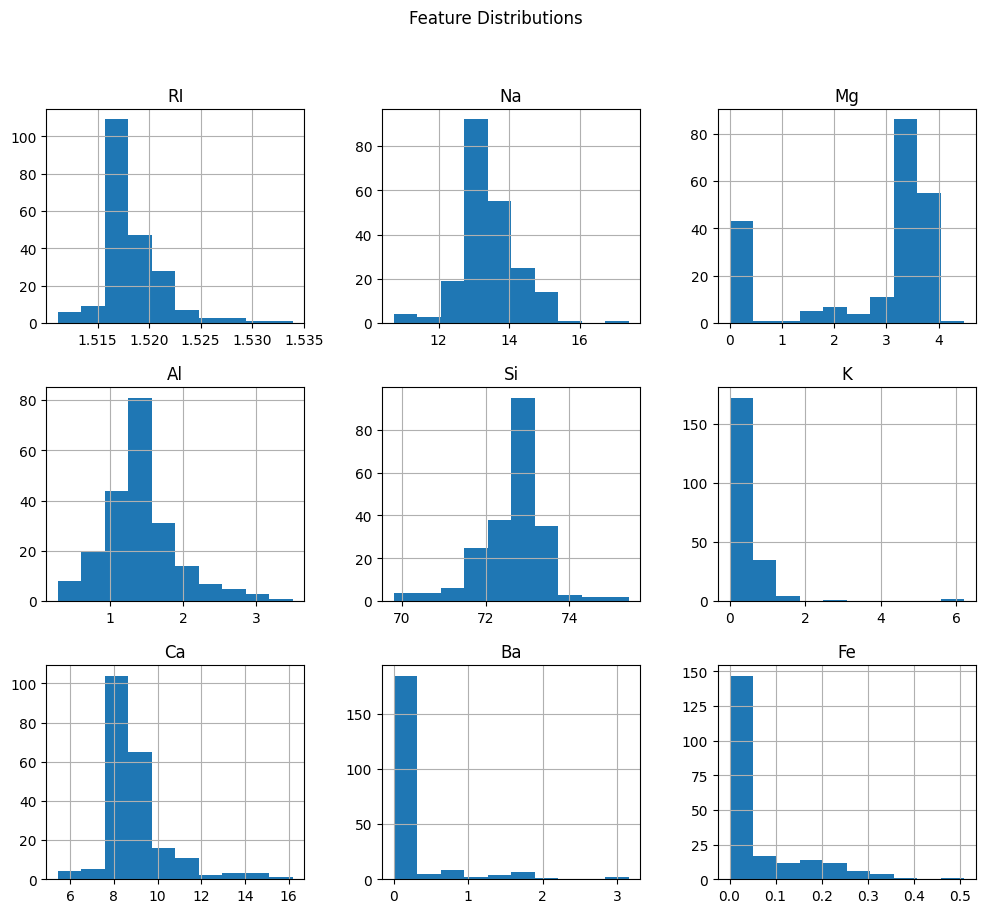


[Analysis - Histograms]
- Some features (RI, Na, Ca) appear normally distributed.
- Some features (Mg, Fe) are skewed.
- This indicates the need for feature scaling (handled using StandardScaler).


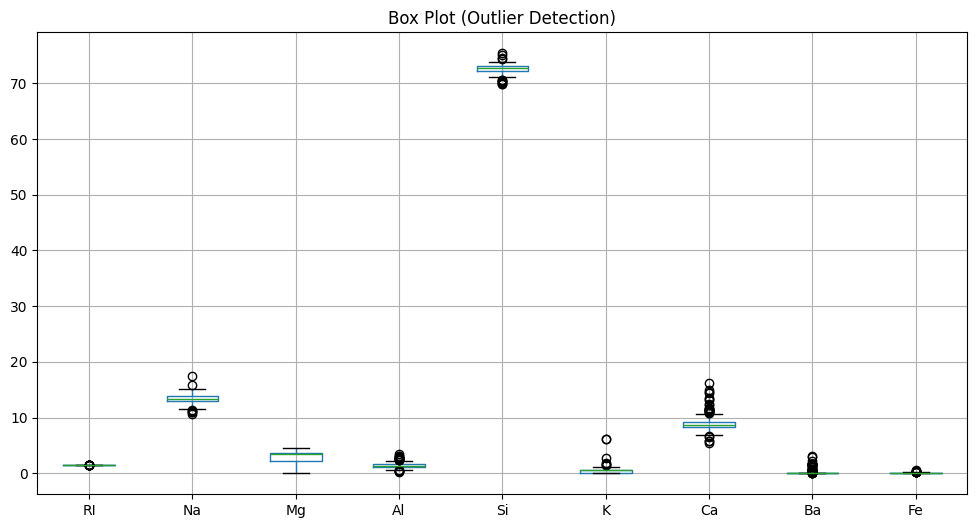


[Analysis - Boxplot]
- Outliers are present in features like Ba, Fe, and Mg.
- Since Random Forest is robust to outliers, no removal was performed.


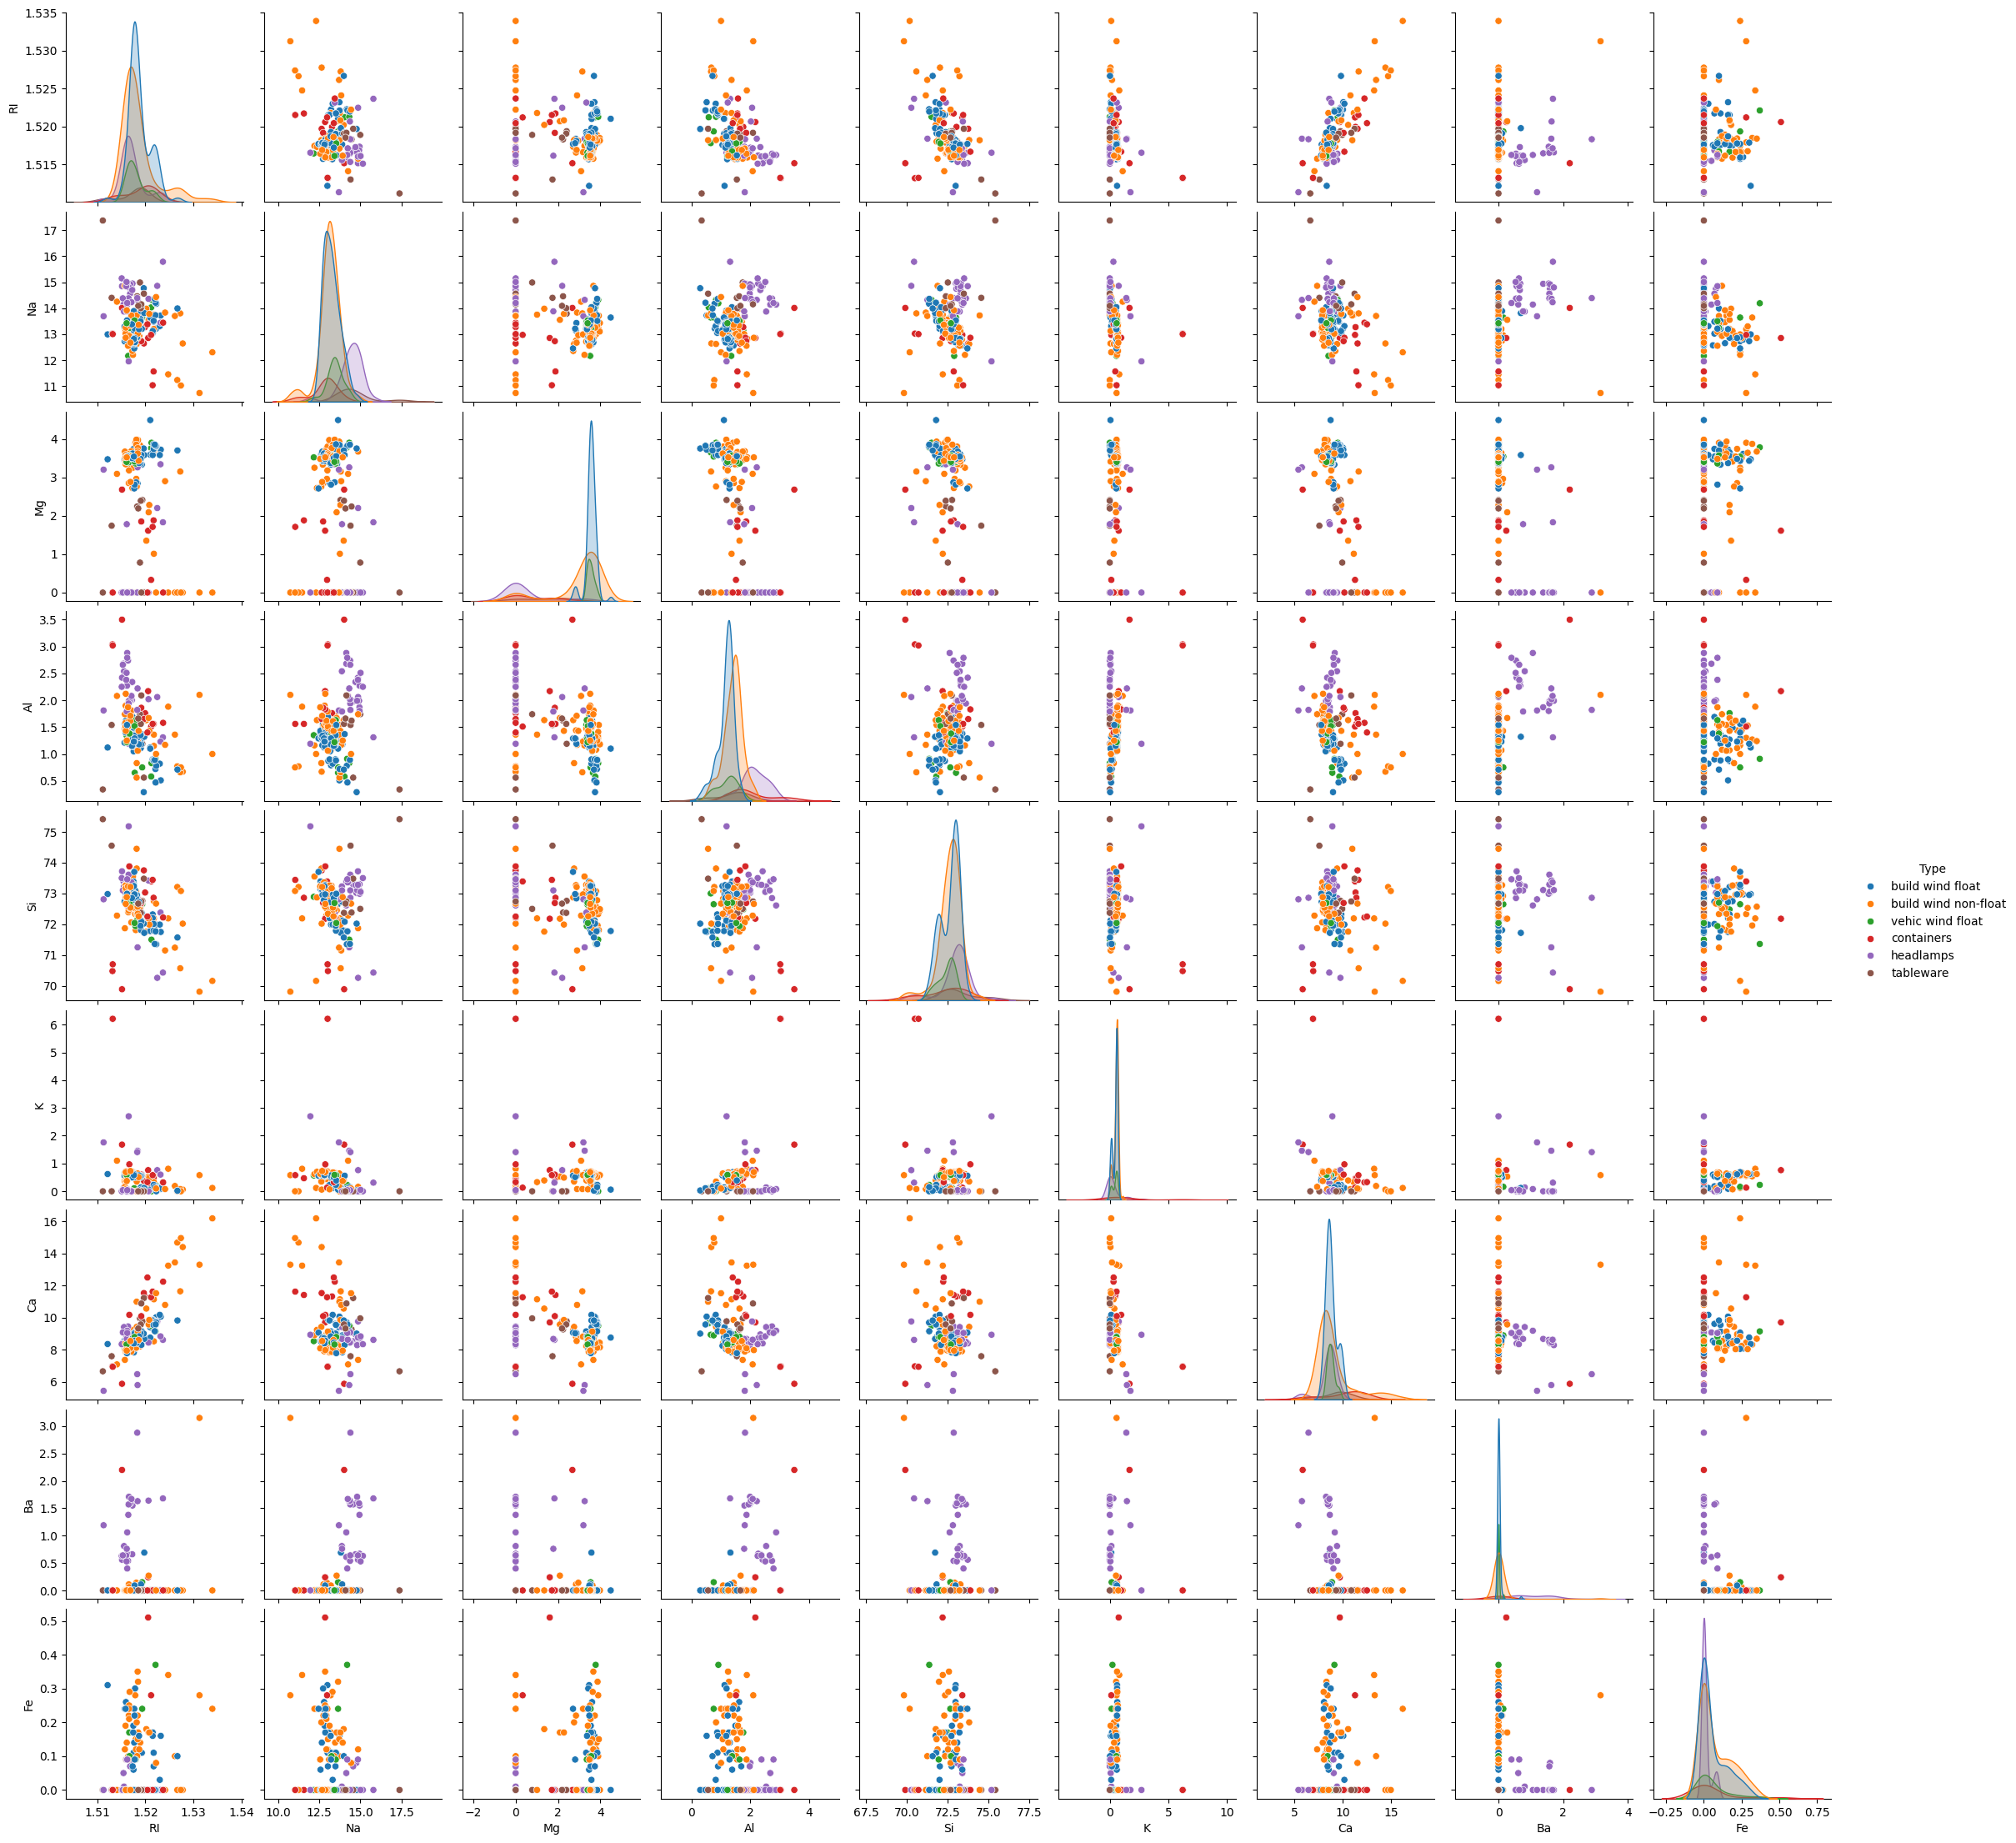


[Analysis - Pairplot]
- Some separation between classes is visible but not linear.
- Indicates that non-linear models (Random Forest) are more suitable.
- Some features show correlation patterns.

[Missing Value Strategy]
- No missing values were found in the dataset.
- Therefore, no imputation was required.
- This avoids introducing artificial noise and preserves original data distribution.

Class Distribution Before SMOTE:
Type
build wind non-float    76
build wind float        70
headlamps               29
vehic wind float        17
containers              13
tableware                9
Name: count, dtype: int64

Class Distribution After SMOTE:
Type
build wind float        76
build wind non-float    76
vehic wind float        76
containers              76
headlamps               76
tableware               76
Name: count, dtype: int64

Random Forest Accuracy: 0.9130434782608695
Random Forest Classification Report:
                      precision    recall  f1-score   support

    bui

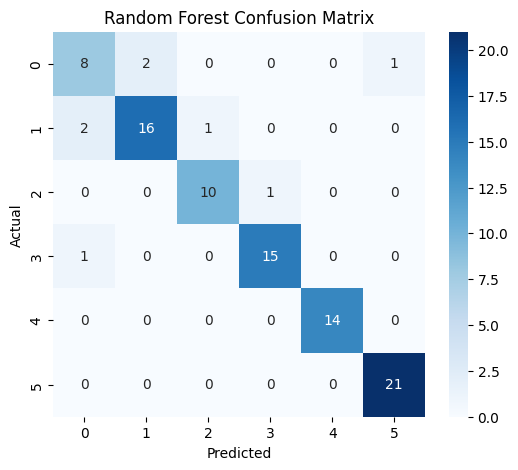

In [1]:
# ============================================================
# RANDOM FOREST ON GLASS DATASET – COMPLETE SINGLE CODE
# ============================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

# -----------------------------
# 2. LOAD GLASS DATASET
# -----------------------------
glass = fetch_openml(name="glass", version=1, as_frame=True)
df = glass.frame
df.rename(columns={"class": "Type"}, inplace=True)

print("Dataset Shape:", df.shape)
print(df.head())

# -----------------------------
# 3. EXPLORATORY DATA ANALYSIS
# -----------------------------
print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

# -----------------------------
# 4. DATA VISUALIZATION
# -----------------------------

# Histograms
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

print("\n[Analysis - Histograms]")
print("- Some features (RI, Na, Ca) appear normally distributed.")
print("- Some features (Mg, Fe) are skewed.")
print("- This indicates the need for feature scaling (handled using StandardScaler).")

# Boxplots
plt.figure(figsize=(12,6))
df.boxplot()
plt.title("Box Plot (Outlier Detection)")
plt.show()

print("\n[Analysis - Boxplot]")
print("- Outliers are present in features like Ba, Fe, and Mg.")
print("- Since Random Forest is robust to outliers, no removal was performed.")

# Pairplot
sns.pairplot(df, hue="Type")
plt.show()

print("\n[Analysis - Pairplot]")
print("- Some separation between classes is visible but not linear.")
print("- Indicates that non-linear models (Random Forest) are more suitable.")
print("- Some features show correlation patterns.")

# -----------------------------
# 5. DATA PREPROCESSING
# -----------------------------

# Features & Target
X = df.drop("Type", axis=1)
y = df["Type"]

# -----------------------------
# MISSING VALUE STRATEGY
# -----------------------------
print("\n[Missing Value Strategy]")
print("- No missing values were found in the dataset.")
print("- Therefore, no imputation was required.")
print("- This avoids introducing artificial noise and preserves original data distribution.")

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check class imbalance
print("\nClass Distribution Before SMOTE:")
print(y.value_counts())

# Handle Imbalanced Data using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print("\nClass Distribution After SMOTE:")
print(pd.Series(y_resampled).value_counts())

# -----------------------------
# 6. TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

# -----------------------------
# 7. RANDOM FOREST MODEL
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# -----------------------------
# 8. BAGGING METHOD
# -----------------------------
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)

print("\nBagging Accuracy:", accuracy_score(y_test, y_pred_bag))
print("Bagging Classification Report:")
print(classification_report(y_test, y_pred_bag))

# -----------------------------
# 9. BOOSTING METHOD (ADABOOST)
# -----------------------------
boosting = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

boosting.fit(X_train, y_train)
y_pred_boost = boosting.predict(X_test)

print("\nBoosting Accuracy:", accuracy_score(y_test, y_pred_boost))
print("Boosting Classification Report:")
print(classification_report(y_test, y_pred_boost))

# -----------------------------
# 10. CONFUSION MATRIX (RANDOM FOREST)
# -----------------------------
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# END OF CODE
# ============================================================

#Additional Notes

#1. Explain Bagging and Boosting methods. How is it different from each other.

🔹 Bagging (Bootstrap Aggregating)

Bootstrap Aggregating is an ensemble learning technique where multiple models are trained independently using different subsets of the training data.

🔑 How it works:

Random samples are drawn with replacement from the dataset

Each sample is used to train a separate model

All models run in parallel

Final prediction is made using majority voting (classification)

🎯 Purpose:

Reduce variance

Prevent overfitting

Improve model stability

🔹 Boosting

AdaBoost is an ensemble technique where models are trained sequentially, and each new model focuses on correcting the errors made by the previous one.

🔑 How it works:

First model is trained normally

Misclassified data points are given higher importance (weights)

Next model focuses more on these difficult samples

Process repeats until performance improves

🎯 Purpose:

Reduce bias

Improve weak learners

Increase overall accuracy






| Aspect         | Bagging                          | Boosting                       |
| -------------- | -------------------------------- | ------------------------------ |
| Training Style | Parallel                         | Sequential                     |
| Main Goal      | Reduce variance                  | Reduce bias                    |
| Data Sampling  | Random sampling with replacement | Weighted sampling              |
| Focus          | All data equally                 | Focus on misclassified samples |
| Overfitting    | Less prone                       | Can overfit if not tuned       |
| Example        | Random Forest                    | AdaBoost                       |


#2. Explain how to handle imbalance in the data.

📌 Handling Imbalanced Data (Short Note)

Imbalanced data occurs when one class has significantly more samples than others, causing the model to become biased toward the majority class.

To handle this, several techniques are used:

Oversampling: Increase minority class samples using methods like SMOTE, which generates synthetic data points.

Undersampling: Reduce majority class samples to balance the dataset.

Class Weighting: Assign higher importance to minority classes during model training.

These methods help improve model performance, especially for minority classes, and ensure more reliable predictions.